IMPORTING THE LIBRARIES


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

LOADING THE DATASETS....


In [4]:

df = pd.read_csv("Loan Approval Prediction.csv")
print(df.shape)
# Display first 5 records
df.head()

(70000, 23)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,0,...,0,0,1,0,0,0,1,0,0,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,1,0,1,0,0,0,0,1,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,0,...,0,0,0,0,0,1,0,0,0,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,...,0,0,1,0,0,1,0,0,0,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,0,...,0,0,1,0,0,1,0,0,0,1


DATASET INFORMATION


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_age                          70000 non-null  float64
 1   person_income                       70000 non-null  float64
 2   person_emp_exp                      70000 non-null  int64  
 3   loan_amnt                           70000 non-null  float64
 4   loan_int_rate                       70000 non-null  float64
 5   loan_percent_income                 70000 non-null  float64
 6   cb_person_cred_hist_length          70000 non-null  float64
 7   credit_score                        70000 non-null  int64  
 8   person_gender_male                  70000 non-null  int64  
 9   person_education_Bachelor           70000 non-null  int64  
 10  person_education_Doctorate          70000 non-null  int64  
 11  person_education_High School        70000

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,loan_status
count,70000.000000,7.000000e+04,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,27.673129,7.297948e+04,5.161043,10020.783871,11.673156,0.162010,5.826657,632.424429,0.463200,0.225586,...,0.001814,0.043943,0.559900,0.145614,0.078386,0.151443,0.121014,0.120043,0.326543,0.500000
std,5.691924,7.056432e+04,5.676875,6623.701599,3.005940,0.099094,3.687981,47.340891,0.498647,0.417970,...,0.042556,0.204969,0.496403,0.352722,0.268780,0.358483,0.326146,0.325014,0.468952,0.500004
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,4.175500e+04,1.000000,5000.000000,9.750000,0.080000,3.000000,603.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,6.102950e+04,4.000000,8457.500000,11.490000,0.140000,4.000000,638.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,30.000000,8.757300e+04,7.000000,14000.000000,13.861052,0.230000,8.000000,667.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


MISSING VALUES


In [6]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_emp_exp,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
credit_score,0
person_gender_male,0
person_education_Bachelor,0


HANDLE MISSING VALUES

In [7]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_3986/3563149562.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


DUPLICATE CHECK

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 7


ENCODING CATEGORICAL FEATURES

In [9]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

EXPLORATORY DATA ANALYSIS(EDA)

Histogram

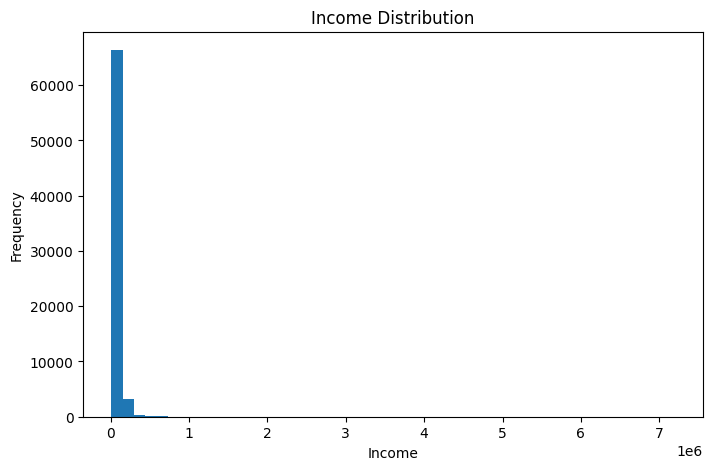

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["person_income"], bins=50)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

Boxplot

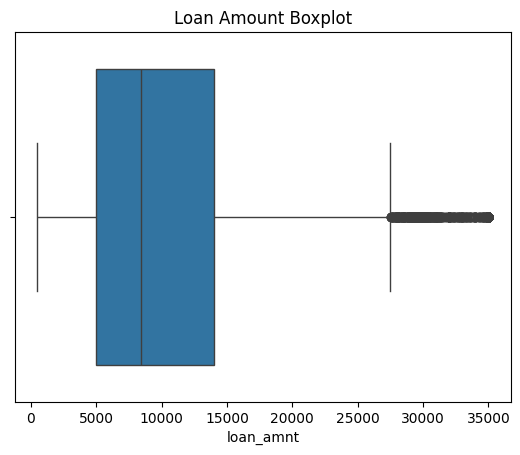

In [11]:
sns.boxplot(x=df["loan_amnt"])

plt.title("Loan Amount Boxplot")
plt.show()

Scatter Plot

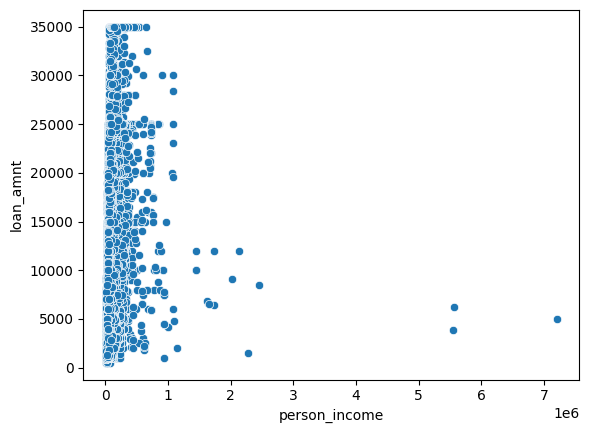

In [12]:
sns.scatterplot(
    x="person_income",
    y="loan_amnt",
    data=df
)

plt.show()

Correlation Heatmap

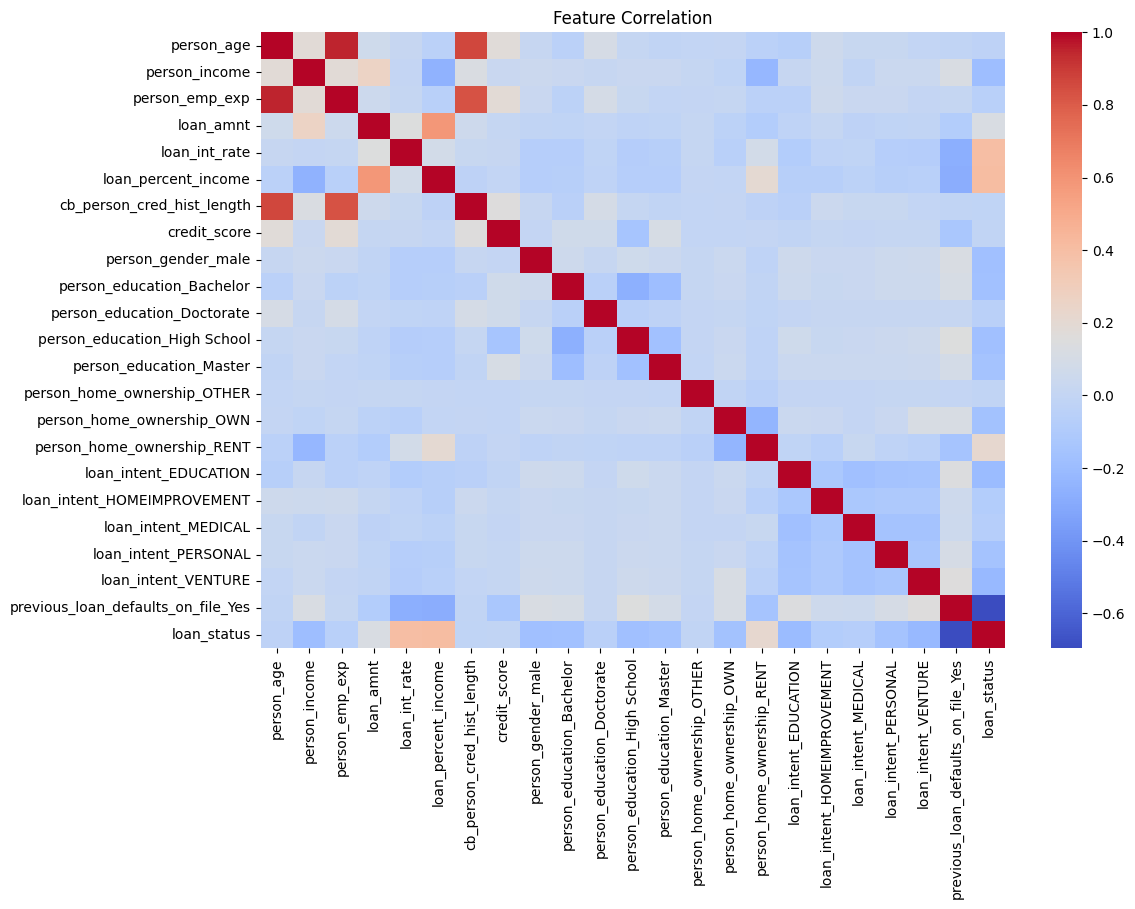

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

FEATURE SELECTION

In [14]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

TRAIN TEST SPLIT

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(56000, 22)
(14000, 22)


RANDOM FOREST MODEL

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9407857142857143


Logistic Regression Model

In [17]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8982857142857142


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CLASSIFICATION REPORT

In [18]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7023
           1       0.93      0.95      0.94      6977

    accuracy                           0.94     14000
   macro avg       0.94      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000



CONFUSION MATRIX

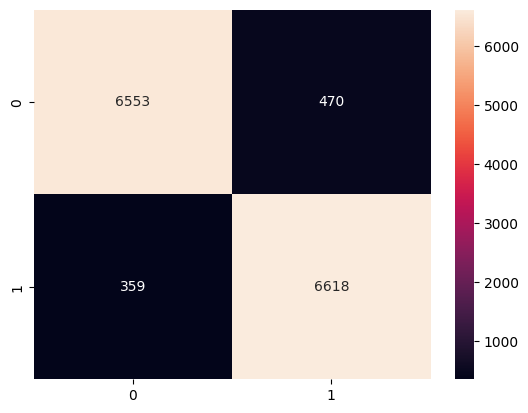

In [19]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

FEATURES ANALYSIS

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                               Feature  Importance
21  previous_loan_defaults_on_file_Yes    0.342175
4                        loan_int_rate    0.135444
5                  loan_percent_income    0.120052
1                        person_income    0.095838
3                            loan_amnt    0.044219
7                         credit_score    0.036418
20                 loan_intent_VENTURE    0.027187
15          person_home_ownership_RENT    0.023285
0                           person_age    0.022173
16               loan_intent_EDUCATION    0.021317
